# 96 - DCGAN on Gaussian Blobs

**Section:** GANs | **Prereqs:** `GANs/Linear_GANs_FMNIST.ipynb` | **Next:** `GANs/CodeChallenge_Guassians_with_fewer_layers.ipynb`

The first **convolutional** GAN, following the DCGAN recipe, on the simplest
possible target: Gaussian blobs. Simple data on purpose - it lets you see whether
the architecture works without the data confusing the picture.

**The two architectures mirror each other**
- **Generator:** `ConvTranspose2d` layers upsampling a `(100,1,1)` noise vector
  to a `(1,64,64)` image. Channels shrink, resolution grows.
- **Discriminator:** `Conv2d` layers with stride 2 shrinking the image back to a
  single number. Channels grow, resolution shrinks.

**Note the noise shape: `(batch, 100, 1, 1)`,** not `(batch, 100)`. The latent
vector is fed as a 1x1 image with 100 channels, so the first `ConvTranspose2d` can
treat it spatially. A frequent source of shape errors when writing a DCGAN from
scratch.

**Why the generator is convolutional at all.** A local kernel applied everywhere
is the right prior for images: neighbouring pixels are related, and the same
pattern can appear anywhere. That is what makes convolutional GANs sharp where
fully connected ones are blurry.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

import torchsummary
import sys

In [ ]:
device = ('cuda' if torch.cuda.is_available() else 'cpu')
device

'cuda'

In [ ]:
# Gaussian blobs at random positions and widths, 64x64 - the same synthetic data
# family as the CNNs section.
# Simple data on purpose: it makes it obvious whether the ARCHITECTURE works.
nImages = 3000
imgSize = 64

x   = np.linspace(-4,4,imgSize)
X,Y = np.meshgrid(x,x)


# initialize tensors containing images and labels
images = torch.zeros(nImages,1,imgSize,imgSize)

for i in range(nImages):

  # create the gaussian with random centers
  ro = 2*np.random.randn(2) # ro = random offset
  width = np.random.rand()/.6 + 1.8 # random width
  G  = np.exp( -( (X-ro[0])**2 + (Y-ro[1])**2) / (2*width**2) )

  # and add noise
  G  = G + np.random.randn(imgSize,imgSize)/5

  # add to the tensor
  images[i,:,:,:] = torch.Tensor(G).view(1,imgSize,imgSize).to(device)

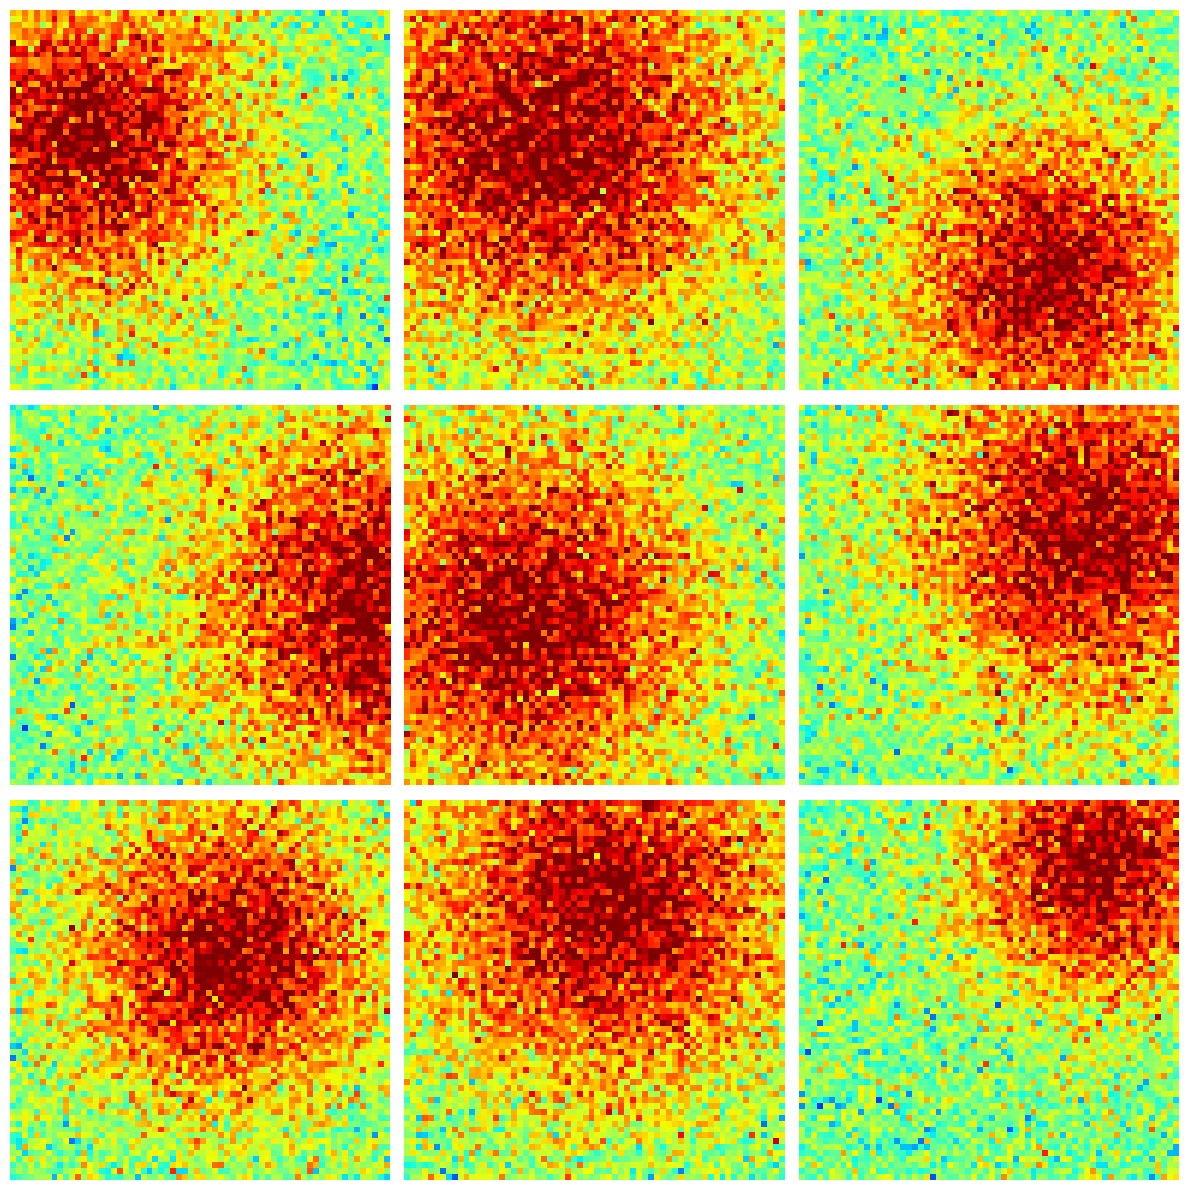

In [ ]:
fig, ax = plt.subplots(3,3, figsize=(12,12))
ax = ax.flatten()


for i in range(min(2*nImages, len(ax))):
  ax[i].imshow(np.squeeze(images[i]), vmin=-1, vmax=1,cmap='jet')
  ax[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
images.shape

torch.Size([3000, 1, 64, 64])

In [ ]:
type(images), images.dtype

(torch.Tensor, torch.float32)

In [ ]:
# Architecture and meta-parameter choices were inspired by https://pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html

# Now we define the models

In [ ]:
# The discriminator: five stride-2 convolutions taking 64x64 down to 1x1.
# 64 -> 32 -> 16 -> 8 -> 4 -> 1, channels growing 1 -> 64 -> 128 -> 256 -> 512 -> 1.
# The DCGAN architecture rules, from the 2015 paper, and they are worth
# following exactly - GANs are fragile and these were found empirically:
#   - stride-2 convolutions instead of pooling (both directions),
#   - BatchNorm everywhere except the generator's output and the
#     discriminator's input layer,
#   - ReLU in the generator, LeakyReLU(0.2) in the discriminator,
#   - Tanh on the generator's output, matching data normalised to [-1,1],
#   - bias=False on any conv followed by BatchNorm (its shift replaces the bias),
#   - Adam with lr=2e-4 and betas=(0.5, 0.999) - the low beta1 matters, since
#     the usual 0.9 keeps too much momentum from a non-stationary objective.
class discriminator(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(1,64,4,2,1,bias=False)
    self.conv2 = nn.Conv2d(64,128,4,2,1,bias=False)
    self.conv3 = nn.Conv2d(128,256,4,2,1,bias=False)
    self.conv4 = nn.Conv2d(256,512,4,2,1,bias=False)
    self.conv5 = nn.Conv2d(512,1,4,2,0,bias=False)

    self.bnorm2 = nn.BatchNorm2d(128)
    self.bnorm3 = nn.BatchNorm2d(256)
    self.bnorm4 = nn.BatchNorm2d(512)


  def forward(self,x):
    x = F.leaky_relu(self.conv1(x),negative_slope=0.2)
    x = self.bnorm2(F.leaky_relu(self.conv2(x),negative_slope=0.2))
    x = self.bnorm3(F.leaky_relu(self.conv3(x),negative_slope=0.2))
    x = self.bnorm4(F.leaky_relu(self.conv4(x),negative_slope=0.2))

    x  = torch.sigmoid( self.conv5(x) ).view(-1,1)

    return x

In [ ]:
dnet = discriminator().to(device)
dnet

discriminator(
  (conv1): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (conv2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (conv3): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (conv4): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (conv5): Conv2d(512, 1, kernel_size=(4, 4), stride=(2, 2), bias=False)
  (bnorm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bnorm3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bnorm4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)

In [ ]:
torchsummary.summary(dnet,(1,64,64),batch_size=10)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [10, 64, 32, 32]           1,024
            Conv2d-2          [10, 128, 16, 16]         131,072
       BatchNorm2d-3          [10, 128, 16, 16]             256
            Conv2d-4            [10, 256, 8, 8]         524,288
       BatchNorm2d-5            [10, 256, 8, 8]             512
            Conv2d-6            [10, 512, 4, 4]       2,097,152
       BatchNorm2d-7            [10, 512, 4, 4]           1,024
            Conv2d-8              [10, 1, 1, 1]           8,192
Total params: 2,763,520
Trainable params: 2,763,520
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.16
Forward/backward pass size (MB): 13.75
Params size (MB): 10.54
Estimated Total Size (MB): 24.45
----------------------------------------------------------------


In [ ]:
dnet(torch.randn((10,1,64,64)).to(device)).shape

torch.Size([10, 1])

In [ ]:
# The generator: the discriminator run backwards.
# ConvTranspose2d from (100,1,1) to (1,64,64), 1 -> 4 -> 8 -> 16 -> 32 -> 64,
# channels shrinking 100 -> 512 -> 256 -> 128 -> 64 -> 1.
# kernel=4 with stride=2 divides evenly, which avoids checkerboard artifacts.
# ReLU throughout, Tanh at the output.
class generatorNet(nn.Module):
  def __init__(self):
    super().__init__()

    # convolution layers
    self.conv1 = nn.ConvTranspose2d(100,512, 4, 1, 0, bias=False)
    self.conv2 = nn.ConvTranspose2d(512,256, 4, 2, 1, bias=False)
    self.conv3 = nn.ConvTranspose2d(256,128, 4, 2, 1, bias=False)
    self.conv4 = nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False)
    self.conv5 = nn.ConvTranspose2d(64,   1, 4, 2, 1, bias=False)

    # batchnorm
    self.bn1 = nn.BatchNorm2d(512)
    self.bn2 = nn.BatchNorm2d(256)
    self.bn3 = nn.BatchNorm2d(128)
    self.bn4 = nn.BatchNorm2d( 64)


  def forward(self,x):

    x = F.relu( self.bn1(self.conv1(x)) )
    x = F.relu( self.bn2(self.conv2(x)) )
    x = F.relu( self.bn3(self.conv3(x)) )
    x = F.relu( self.bn4(self.conv4(x)) )
    x = torch.tanh( self.conv5(x) )

    return x

torch.Size([10, 1, 64, 64])


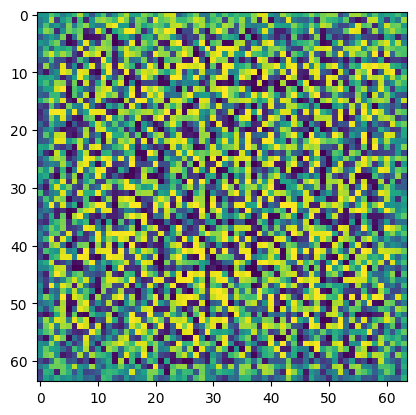

In [ ]:
# Generating from noise. NOTE the shape: (batch, 100, 1, 1), not (batch, 100).
# The latent vector is fed as a 1x1 image with 100 channels so the first
# ConvTranspose2d can treat it spatially. This trips up almost everyone writing
# a DCGAN for the first time.
gnet = generatorNet().to(device)

y = gnet(torch.randn(10,100,1,1).to(device))
print(y.shape)
plt.imshow(y[0].squeeze().detach().cpu().numpy());

In [ ]:
dnet(y).shape

torch.Size([10, 1])

## Training the model

In [ ]:
# Adam with betas=(0.5, 0.999). The lowered beta1 is a DCGAN recommendation:
# the default 0.9 carries too much momentum for an objective that keeps moving,
# and it makes training oscillate.
lossfunc = nn.BCELoss()

epochs = 10500
batchsize = 72

d_optimizer = torch.optim.Adam(dnet.parameters(), lr=.0001, betas=(.5,.999))
g_optimizer = torch.optim.Adam(gnet.parameters(), lr=.0001, betas=(.5,.999))

In [ ]:
torch.randint(images.shape[0],(batchsize,)) # High = image.shape[0], and chosses random digits of the size (batchsize,)

tensor([2527, 1062, 2699,  858, 1881, 2782, 1808,  474, 1274, 2403,  758, 2717,
         927, 1310,  819, 2228, 2940, 2750, 1161,  806, 1720, 2691, 1546,  390,
        2558, 1543,  134,  279, 2340, 2165, 1810,  157, 1102, 2263, 1375,  286,
         576, 2474, 2023,  145,  702, 1672, 1843, 1081, 1010,  316,  589, 2744,
         600, 2732, 1608, 2213, 2075,  686, 1558, 1906, 1597, 1019, 2003, 2830,
         225,  547, 1736,  573, 1297, 1395, 2176, 2591, 1462,  677, 2068, 2748])

In [ ]:
# THE GAN TRAINING LOOP. Two models, two optimizers, one alternating step:
#
# 1. DISCRIMINATOR: show it real images labelled 1 and fake images labelled 0,
#    and minimise BCE on both. It learns to tell them apart.
# 2. GENERATOR: make fresh fakes, run them through the discriminator, and
#    minimise BCE against label 1 - i.e. train the generator to make the
#    discriminator say 'real'.
#
# The label flip in step 2 is the whole trick: the generator has no direct
# target image, only the discriminator's opinion, so 'be more convincing' is
# expressed as 'make D output 1'.
#
# Fakes are REGENERATED between the two steps. Reusing the step-1 fakes would
# backpropagate through a stale graph, and torch would raise.
#
# What to watch: d_loss and g_loss should stay in tension. If d_loss collapses
# to 0 the discriminator won and the generator gets no useful gradient; if
# g_loss collapses the generator found a blind spot. Neither loss going to zero
# is success - equilibrium is.
losses = torch.zeros((epochs,2))
dnet_decisions = torch.zeros((epochs,2))

# How many times to train the generator per discriminator update
k_g = 2

for epoch in range(epochs):

  randidx = torch.randint(images.shape[0],(batchsize,))
  real_images = images[randidx,:].to(device)
  fake_images = gnet( torch.randn((batchsize,100,1,1)).to(device) )

  real_labels = torch.ones((batchsize,1),device=device)
  fake_labels = torch.zeros((batchsize,1), device=device)

  # Training the discriminator

  pred_real = dnet(real_images)
  d_loss_real = lossfunc(pred_real, real_labels)

  pred_fake = dnet(fake_images)
  d_loss_fake = lossfunc(pred_fake, fake_labels)

  d_loss = d_loss_real + d_loss_fake

  losses[epoch,0] = d_loss.item()
  dnet_decisions[epoch,0] = torch.mean((pred_real > 0.5).float()).detach()

  d_optimizer.zero_grad()
  d_loss.backward()
  d_optimizer.step()

  # Training the generator (k_g times)
  for _ in range(k_g):
    fake_images = gnet(torch.randn((batchsize,100,1,1)).to(device))
    fake_preds = dnet(fake_images)

    g_loss = lossfunc(fake_preds, real_labels) # We compare the predictions to the real images

    g_optimizer.zero_grad()
    g_loss.backward()
    g_optimizer.step()

  losses[epoch,1] = g_loss.item()
  dnet_decisions[epoch,1] = torch.mean((fake_preds > 0.5).float()).detach()


  if (epoch+1) % 100 == 0 or epoch == epochs -1:

    msg = f'Epoch {epoch+1}/{epochs}'
    sys.stdout.write('\r' + msg)
    sys.stdout.flush()


Epoch 10500/10500

In [ ]:
def smooth(x,k=15):
  return np.convolve(x,np.ones(k)/k,mode='same')

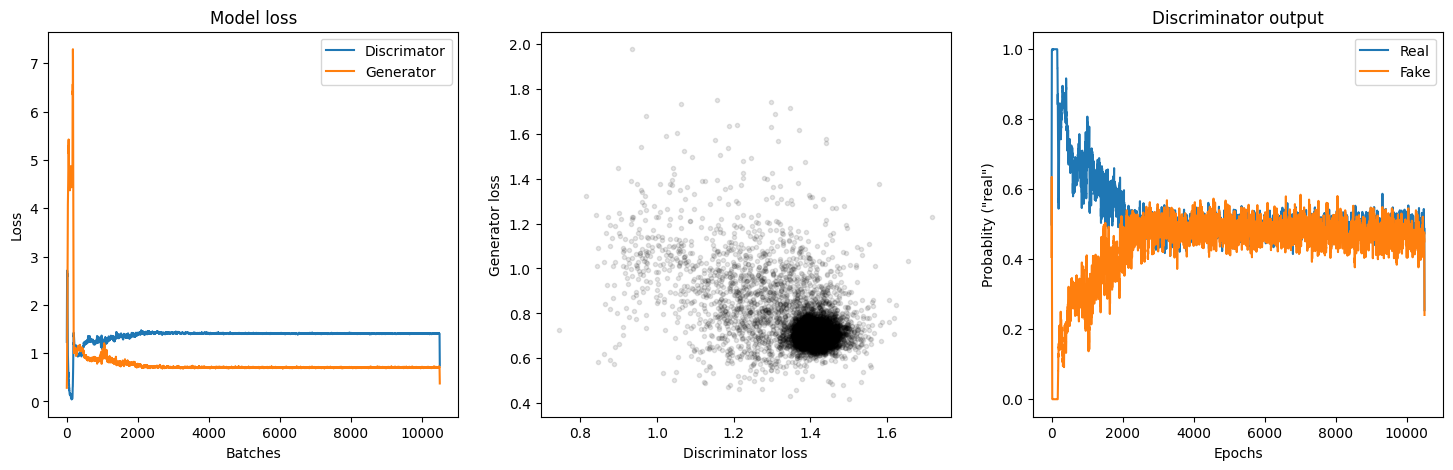

In [ ]:
# The three GAN diagnostics:
# LEFT   - both losses over time. Look for sustained oscillation, not
#          convergence. A GAN that 'converges' has usually collapsed.
# MIDDLE - discriminator loss against generator loss. A diagonal cloud means the
#          two are trading blows; a point in one corner means one has won.
# RIGHT  - the discriminator's decisions on real and fake. At equilibrium both
#          approach 0.5: it can no longer tell them apart. That is the target,
#          and it is the closest thing a GAN has to an accuracy metric.
fig,ax = plt.subplots(1,3,figsize=(18,5))

ax[0].plot(smooth(losses[:,0]))
ax[0].plot(smooth(losses[:,1]))
ax[0].set_xlabel('Batches')
ax[0].set_ylabel('Loss')
ax[0].set_title('Model loss')
ax[0].legend(['Discrimator','Generator'])
# ax[0].set_xlim([500,900])
# ax[0].set_ylim([0,2.5])

ax[1].plot(losses[200:,0],losses[200:,1],'k.',alpha=.1)
ax[1].set_xlabel('Discriminator loss')
ax[1].set_ylabel('Generator loss')

ax[2].plot(smooth(dnet_decisions[:,0]))
ax[2].plot(smooth(dnet_decisions[:,1]))
ax[2].set_xlabel('Epochs')
ax[2].set_ylabel('Probablity ("real")')
ax[2].set_title('Discriminator output')
ax[2].legend(['Real','Fake'])

plt.show()

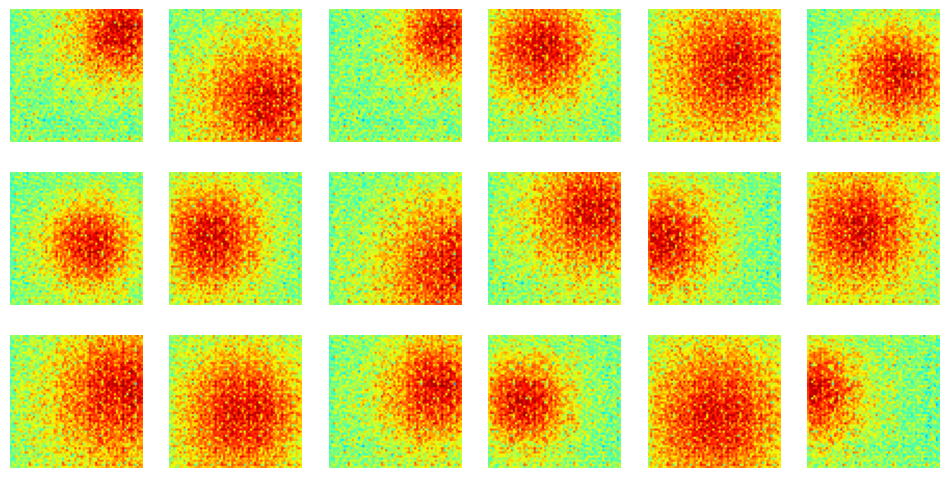

In [ ]:
# Generated blobs. On data this simple a working DCGAN should produce clean,
# varied Gaussians - which is the point of testing an architecture on easy data
# before pointing it at something hard.
gnet.eval()
fake_data = gnet( torch.randn(batchsize,100,1,1).to(device) ).cpu()

# and visualize...
fig,axs = plt.subplots(3,6,figsize=(12,6))
for i,ax in enumerate(axs.flatten()):
  ax.imshow(fake_data[i,].detach().squeeze(),cmap='jet',vmin=-1,vmax=1)
  ax.axis('off')

plt.show()